# Lección 2.1: Gráficos de Líneas y Uso de Metadata
Notebook práctico completo: incluye limpieza, transposición, comparación de librerías, trazado de series individuales y **agregaciones regionales combinando `population.csv` con `metadata.csv`**.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga de Datasets
population = pd.read_csv('2.0 Population.csv')
metadata = pd.read_csv('2.0 Metadata.csv')

## 1. Preparación y Reestructuración de Múltiples Series

In [3]:
# Filtrar países de Norteamérica
north_america = population[population['Country Name'].isin(['Mexico', 'United States', 'Canada'])].copy()
north_america.set_index('Country Name', inplace=True)
if 'Country Code' in north_america.columns:
    north_america.drop('Country Code', axis=1, inplace=True)

# Transponer para colocar el tiempo en las filas
north_america = north_america.T
north_america.index.name = 'Year'
north_america.columns.name = ''

north_america.head()

,Canada,Mexico,United States
Year,,,
1960,17909356.0,36724615.0,180671000.0
1961,18271000.0,37890118.0,183691000.0
1962,18614000.0,39129200.0,186538000.0
1963,18964000.0,40424065.0,189242000.0
1964,19325000.0,41772049.0,191889000.0


## 2. Comparativa de Librerías (Pandas, Matplotlib, Seaborn)

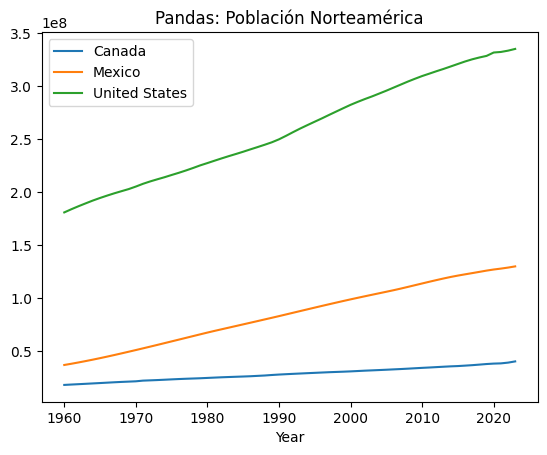

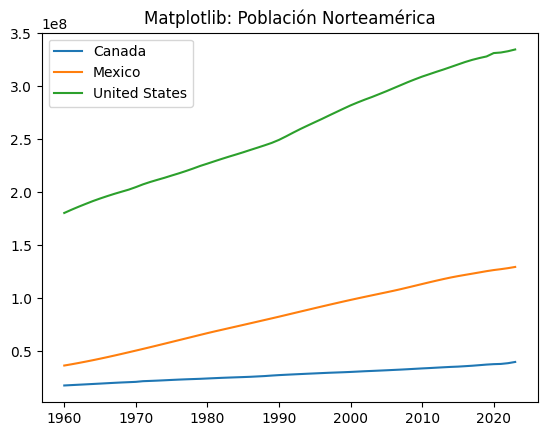

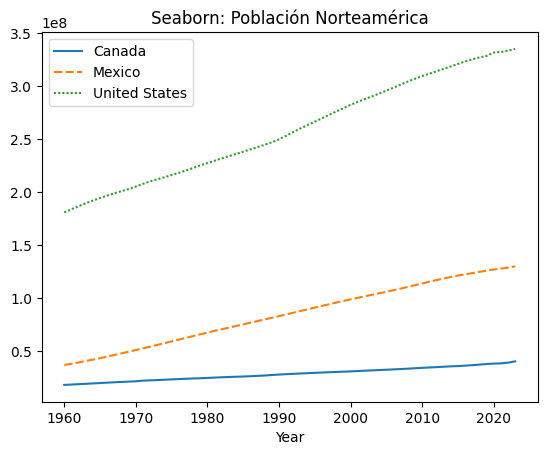

In [4]:
# --- 2.1 Pandas ---
north_america.plot(title="Pandas: Población Norteamérica")
plt.xticks(np.arange(0, len(north_america), 10))
plt.show()

# --- 2.2 Matplotlib ---
plt.figure()
plt.plot(north_america)
plt.title("Matplotlib: Población Norteamérica")
plt.legend(north_america.columns)
plt.xticks(np.arange(0, len(north_america), 10))
plt.show()

# --- 2.3 Seaborn ---
plt.figure()
sns.lineplot(data=north_america)
plt.title("Seaborn: Población Norteamérica")
plt.xticks(np.arange(0, len(north_america), 10))
plt.show()

## 3. Uso del CSV de Metadata: Combinación y Agrupación (`groupby`)

In [5]:
# Unir los datos de población con los metadatos de cada país usando 'Country Code'
merged_df = population.merge(metadata, on='Country Code')

# Agrupar la población total por Región para el año 2023
region_population = merged_df.groupby('Region')['2023'].sum()

print("Población total por región (2023):")
print(region_population)

Población total por región (2023):
Region
East Asia & Pacific           2361090328
Europe & Central Asia          924969865
Latin America & Caribbean      657611624
Middle East & North Africa     508311359
North America                  375077354
South Asia                    1951539835
Sub-Saharan Africa            1259902353
Name: 2023, dtype: int64


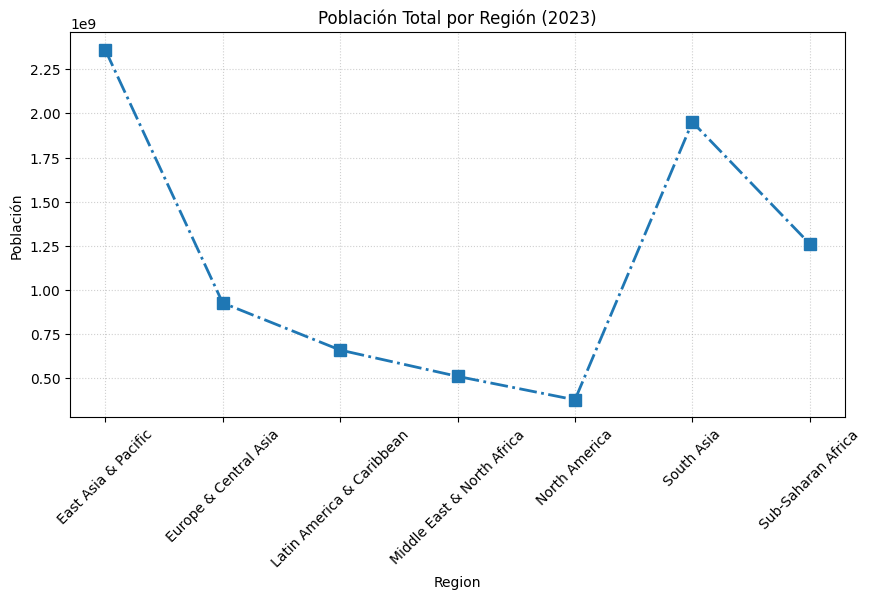

In [6]:
# Graficar el resultado del groupby usando kwargs personalizados
region_population.plot(
    kind='line',
    figsize=(10, 5),
    title="Población Total por Región (2023)",
    rot=45,
    linestyle='-.',
    linewidth=2,
    marker='s',
    markersize=8
)
plt.ylabel("Población")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 4. Personalización Avanzada (**kwargs)

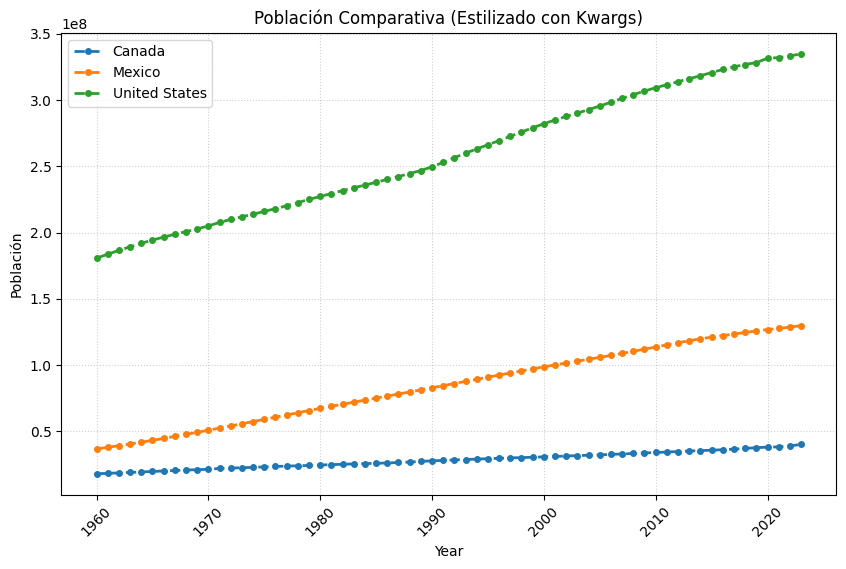

In [7]:
north_america.plot(
    figsize=(10, 6),
    title="Población Comparativa (Estilizado con Kwargs)",
    rot=45,
    linestyle='--',
    linewidth=2,
    marker='o',
    markersize=4
)
plt.xticks(np.arange(0, len(north_america), 10))
plt.ylabel("Población")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()